In [1]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
model = load_model('../models/best_model_finetuned.keras')

with open('../models/class_indices.json', 'r') as f:
    class_indices = json.load(f)

CLASSES = list(class_indices.keys())
TEST_DIR = '../dataset/Test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Model loaded!")
print("Classes:", CLASSES)

Model loaded!
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Test samples: {test_generator.samples}")
print(f"Class indices: {test_generator.class_indices}")

Found 2414 images belonging to 4 classes.
Test samples: 2414
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [4]:
print("Running predictions on test set...")
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

print(f"Predictions done!")
print(f"Total predictions: {len(y_pred)}")

Running predictions on test set...
76/76 [==============================] - 18s 147ms/step
Predictions done!
Total predictions: 2414


In [16]:
print("=" * 60)
print("                   CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASSES))

                   CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.81      0.61      0.69       755
  meningioma       0.55      0.45      0.50       546
     notumor       0.76      0.98      0.85       487
   pituitary       0.80      0.97      0.87       626

    accuracy                           0.74      2414
   macro avg       0.73      0.75      0.73      2414
weighted avg       0.74      0.74      0.73      2414



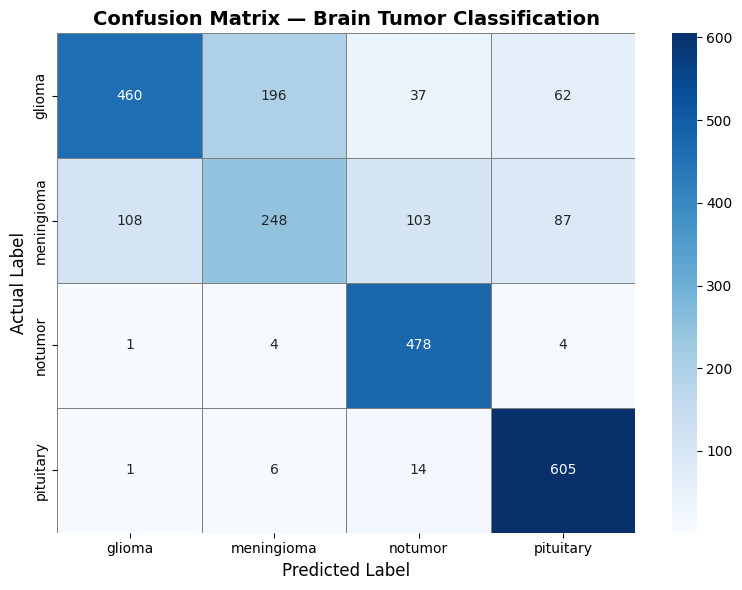

In [8]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — Brain Tumor Classification', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


In [9]:
print("Per Class Accuracy:")
print("-" * 40)
for i, cls in enumerate(CLASSES):
    cls_mask = y_true == i
    cls_acc = np.mean(y_pred[cls_mask] == y_true[cls_mask])
    print(f"  {cls:15s}: {cls_acc*100:.2f}%")

Per Class Accuracy:
----------------------------------------
  glioma         : 60.93%
  meningioma     : 45.42%
  notumor        : 98.15%
  pituitary      : 96.65%


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print("=" * 40)
print("         FINAL MODEL METRICS")
print("=" * 40)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print("=" * 40)

         FINAL MODEL METRICS
  Accuracy  : 74.19%
  Precision : 73.55%
  Recall    : 74.19%
  F1 Score  : 72.84%


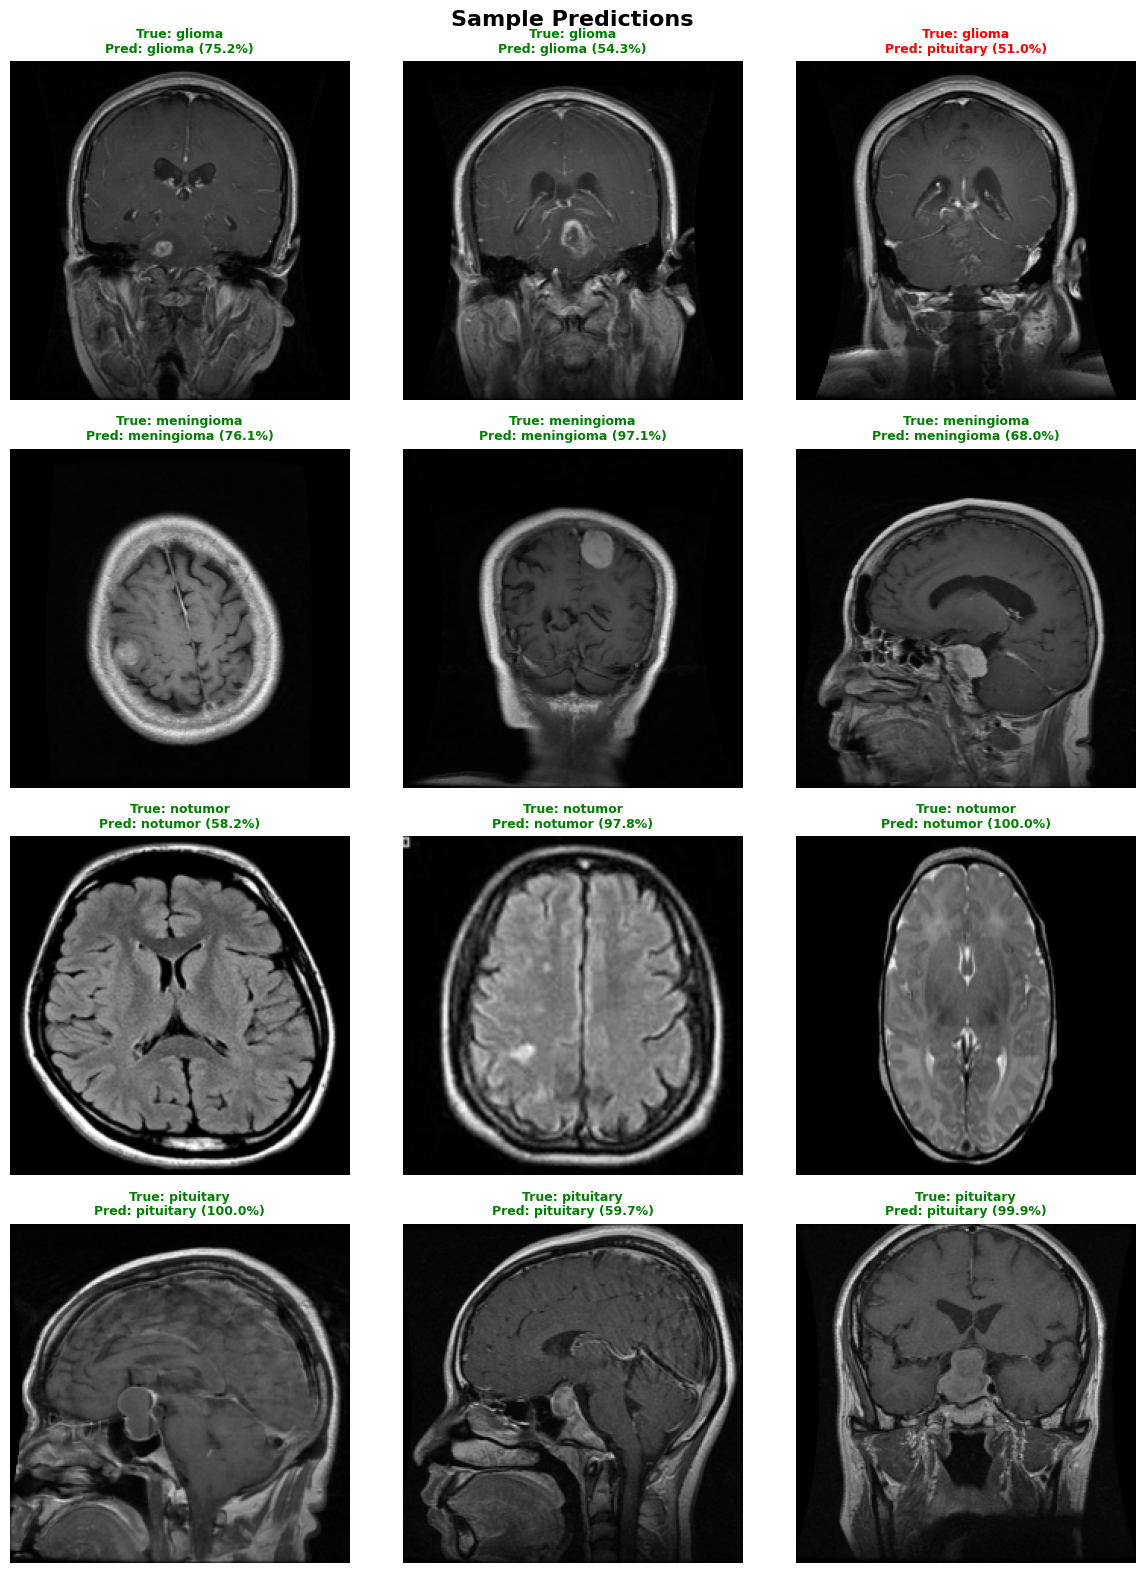

In [12]:
import cv2

test_images = []
test_labels = []

for cls in CLASSES:
    cls_path = os.path.join(TEST_DIR, cls)
    imgs = os.listdir(cls_path)[:3]
    for img_name in imgs:
        img = cv2.imread(os.path.join(cls_path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        test_images.append(img)
        test_labels.append(cls)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Sample Predictions', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    img = test_images[idx]
    true_label = test_labels[idx]
    
    img_input = img / 255.0
    img_input = np.expand_dims(img_input, axis=0)
    pred_probs = model.predict(img_input, verbose=0)
    pred_label = CLASSES[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100
    
    ax.imshow(img)
    ax.axis('off')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

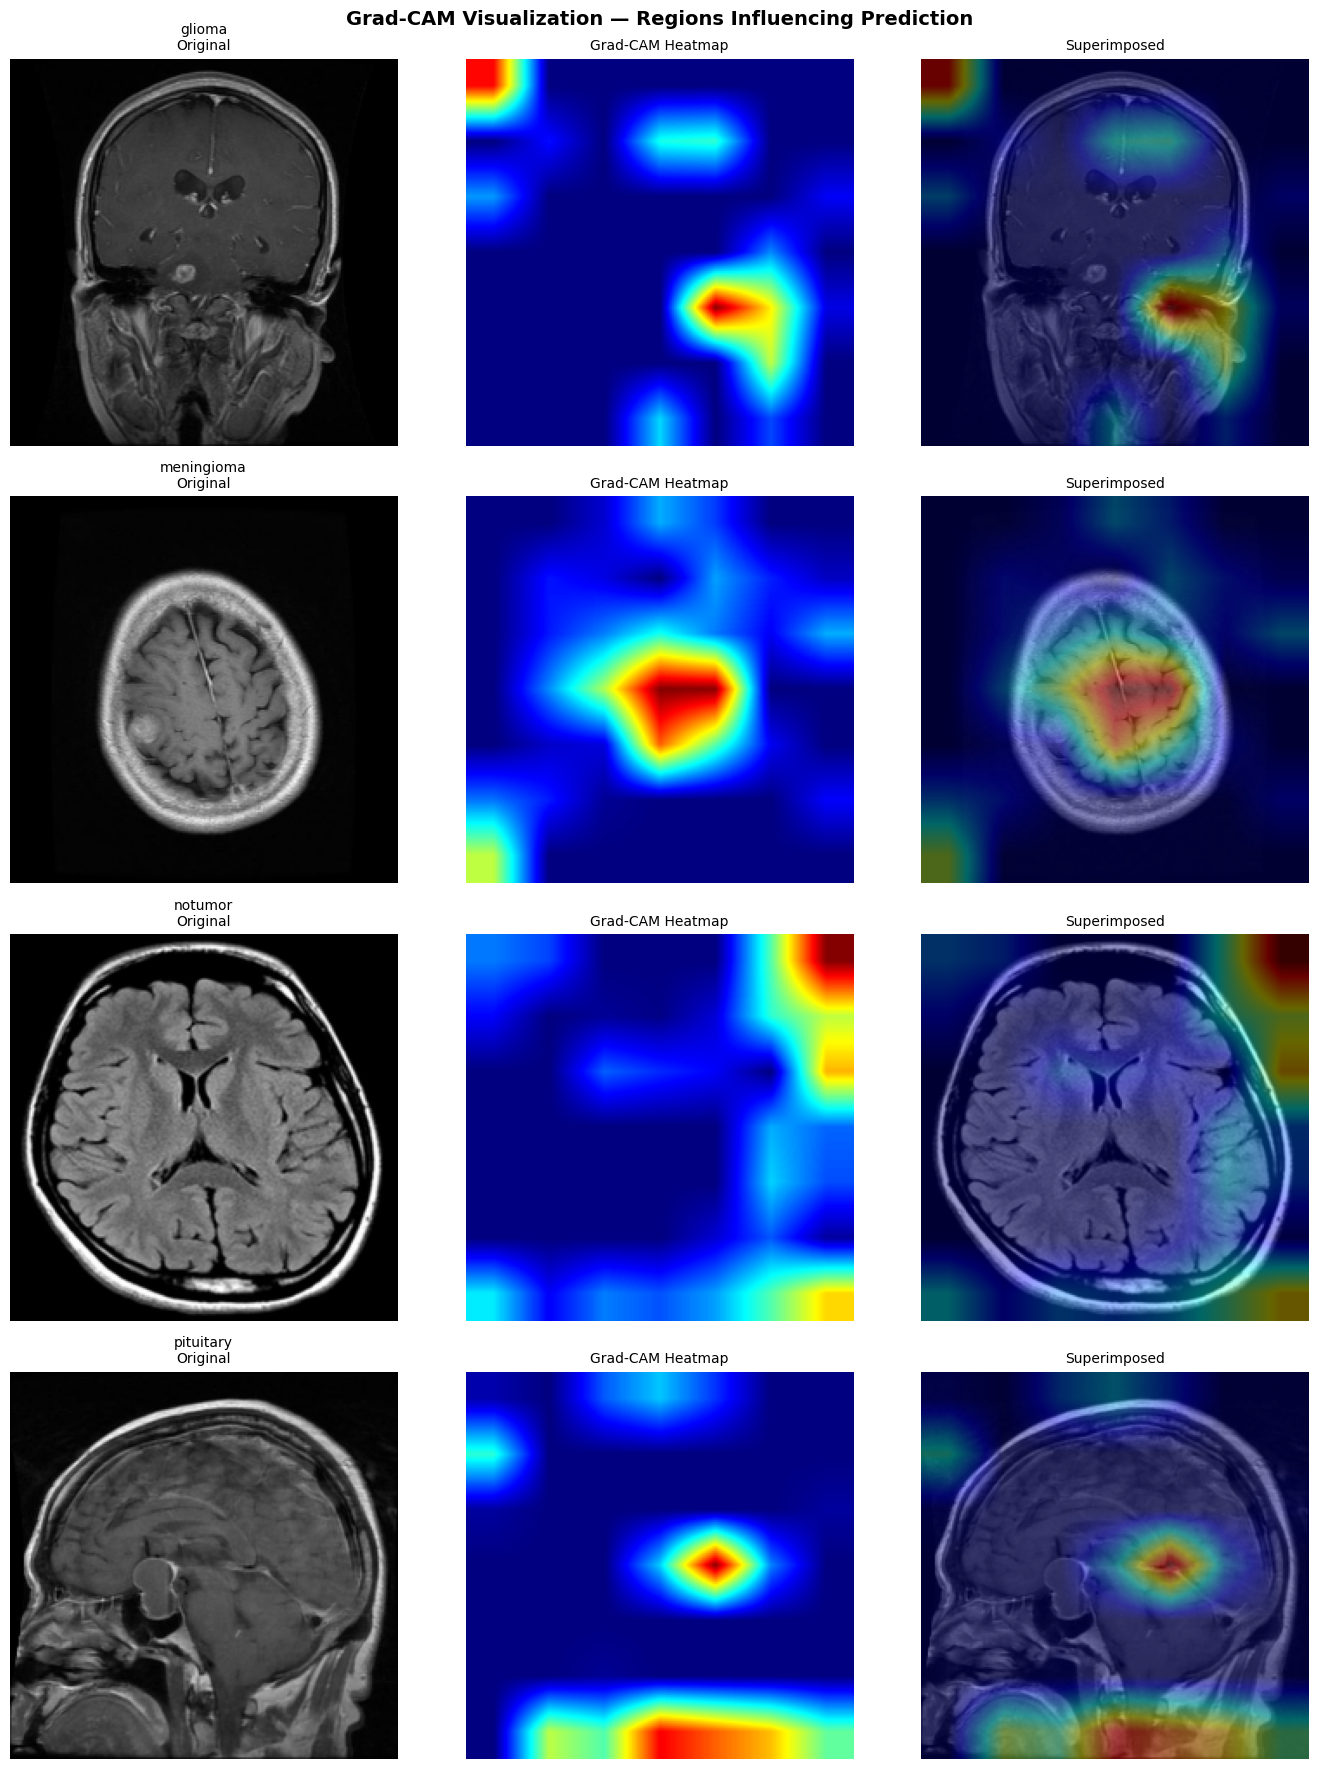

In [17]:
import sys
sys.path.append('../utils')
from gradcam import apply_gradcam
import os

fig, axes = plt.subplots(4, 3, figsize=(14, 18))
fig.suptitle('Grad-CAM Visualization — Regions Influencing Prediction',
             fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(TEST_DIR, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    original, heatmap, superimposed = apply_gradcam(model, img_path)

    axes[row][0].imshow(original)
    axes[row][0].set_title(f'{cls}\nOriginal', fontsize=10)
    axes[row][0].axis('off')

    axes[row][1].imshow(heatmap)
    axes[row][1].set_title('Grad-CAM Heatmap', fontsize=10)
    axes[row][1].axis('off')

    axes[row][2].imshow(superimposed)
    axes[row][2].set_title('Superimposed', fontsize=10)
    axes[row][2].axis('off')

plt.tight_layout()
plt.show()
